# Signal Analysis

## Step 1: Notebook setup and frequency-domain definition

In this notebook, I will simulate and analyze radio astronomy signals by following the required workflow:
- signal simulation
- smoothing
- calibration
- spectral line detection
- upsampling
- fitting
- error estimation

The analysis is centered around the hydrogen spectral line at 1420 MHz.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal import find_peaks

In [2]:
# Reproducibility
np.random.seed(42)

# Plot settings
plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True

In [3]:
# Frequency-domain parameters
n_samples = 512
f_min = 1418.0
f_max = 1422.0
freq = np.linspace(f_min, f_max, n_samples)

# Time-domain parameter for the waterfall
n_seg = 80

# Hydrogen line frequency
f0 = 1420.0

# Basic checks
bandwidth = f_max - f_min
frequency_resolution = bandwidth / (n_samples - 1)

print(f"Number of frequency samples: {n_samples}")
print(f"Frequency range: {f_min:.3f} - {f_max:.3f} MHz")
print(f"Bandwidth: {bandwidth:.3f} MHz")
print(f"Frequency resolution: {frequency_resolution:.6f} MHz")
print(f"Number of time segments: {n_seg}")
print(f"Hydrogen line center: {f0:.3f} MHz")

Number of frequency samples: 512
Frequency range: 1418.000 - 1422.000 MHz
Bandwidth: 4.000 MHz
Frequency resolution: 0.007828 MHz
Number of time segments: 80
Hydrogen line center: 1420.000 MHz


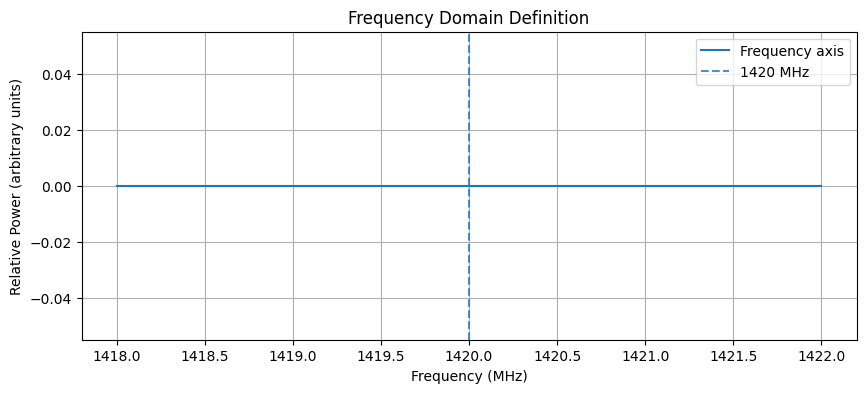

In [4]:
plt.plot(freq, np.zeros_like(freq), label="Frequency axis")
plt.axvline(f0, linestyle="--", alpha=0.8, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power (arbitrary units)")
plt.title("Frequency Domain Definition")
plt.legend()
plt.show()

### Step 1 summary

The frequency axis has been defined around the hydrogen line at 1420 MHz, with a total bandwidth of 4 MHz and 512 samples.  
This provides the basis for simulating the OFF and ON radio signals in the next step.

## Step 2: Background modeling and OFF signal simulation

In this step, we simulate the OFF signal, which consists of:
- a smooth background signal
- Gaussian noise that varies across time segments

The OFF signal does not contain any spectral line and will later be used for calibration.

In [5]:
def background_model(f):
  x = (f - np.mean(f)) / (f.max() - f.min())

  bg = (
      13.2
      + 3.8 * x**4
      + 0.35 * np.sin(2 * np.pi * 1.3 * x)
      - 0.20 * np.cos(2 * np.pi * 2.1 * x)
  )

  return bg

background = background_model(freq)

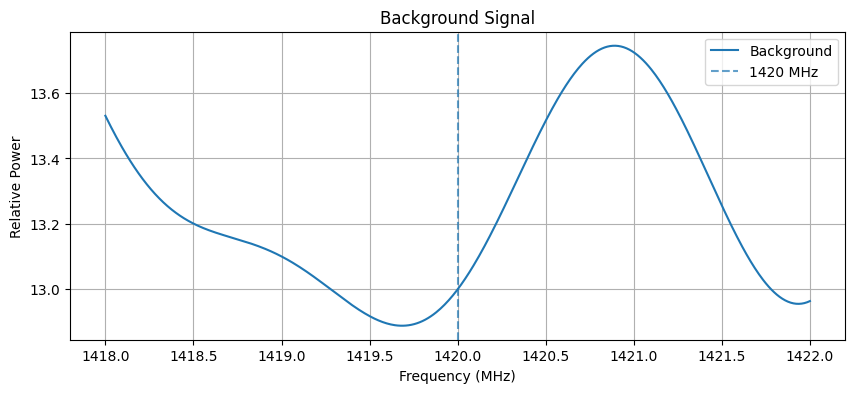

In [6]:
plt.plot(freq, background, label="Background")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Background Signal")
plt.legend()
plt.show()

In [7]:
noise_std = 0.12

off_signal = np.array([
    background + np.random.normal(0, noise_std, size=n_samples)
    for _ in range(n_seg)
])

In [8]:
print(off_signal.shape)

(80, 512)


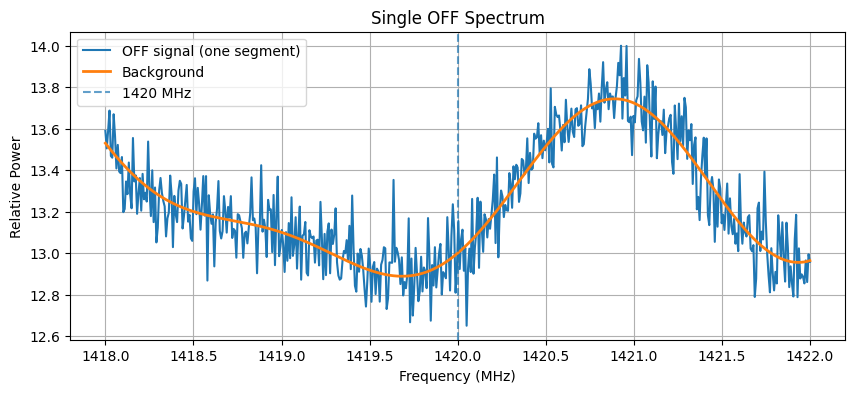

In [9]:
plt.plot(freq, off_signal[0], label="OFF signal (one segment)")
plt.plot(freq, background, linewidth=2, label="Background")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Single OFF Spectrum")
plt.legend()
plt.show()

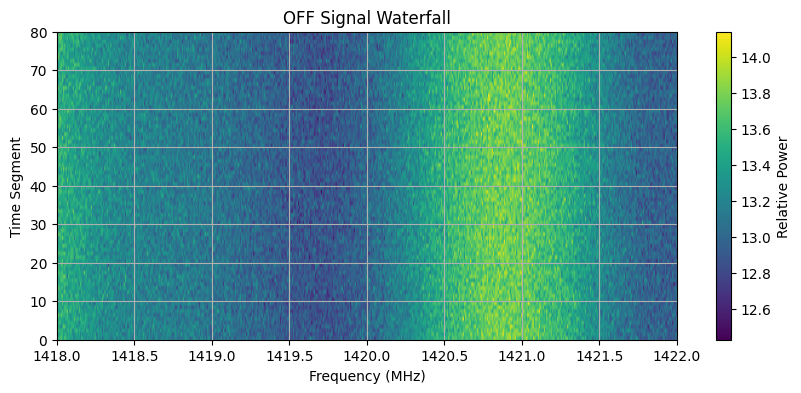

In [10]:
plt.imshow(
    off_signal,
    aspect="auto",
    origin="lower",
    extent=[f_min, f_max, 0, n_seg],
)

plt.colorbar(label="Relative Power")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Time Segment")
plt.title("OFF Signal Waterfall")
plt.show()

## Step 3: ON signal and spectral line simulation

In this step, I simulate the ON signal by adding a hydrogen spectral line at 1420 MHz on top of the same background used for the OFF signal.

I also create:
- `spectral`: the clean spectral line with the original number of samples
- `spectral2`: the same spectral line with twice the number of samples

These clean signals will later be used as references for fitting and error estimation.

In [11]:
def gaussian_line(f, amplitude, center, sigma):
  return amplitude * np.exp(-0.5 * ((f - center) / sigma) ** 2)

In [12]:
line_amplitude = 0.55
line_sigma = 0.06

spectral = gaussian_line(
    freq,
    amplitude=line_amplitude,
    center=f0,
    sigma=line_sigma
)

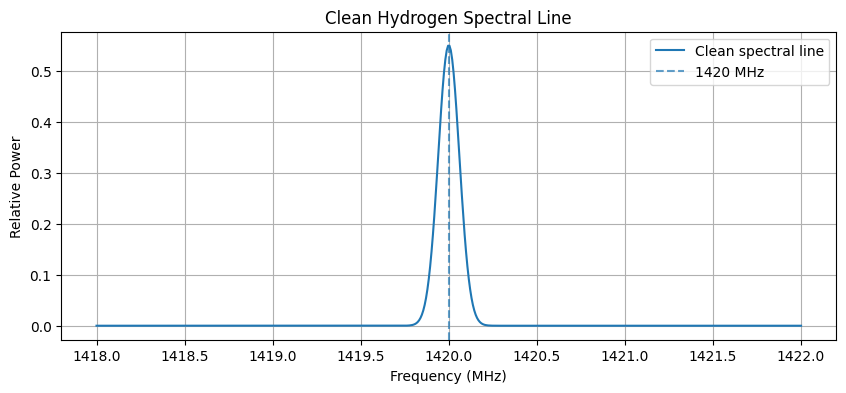

In [13]:
plt.plot(freq, spectral, label="Clean spectral line")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Clean Hydrogen Spectral Line")
plt.legend()
plt.show()

In [14]:
on_signal = np.array([
    background + spectral + np.random.normal(0, noise_std, size=n_samples)
    for _ in range(n_seg)
])

In [15]:
print("OFF signal shape:", off_signal.shape)
print("ON signal shape:", on_signal.shape)
print("Spectral shape:", spectral.shape)

OFF signal shape: (80, 512)
ON signal shape: (80, 512)
Spectral shape: (512,)


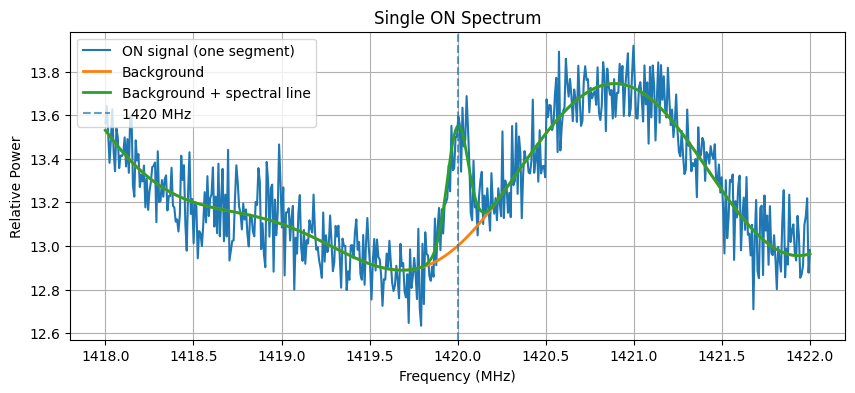

In [16]:
plt.plot(freq, on_signal[0], label="ON signal (one segment)")
plt.plot(freq, background, linewidth=2, label="Background")
plt.plot(freq, background + spectral, linewidth=2, label="Background + spectral line")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Single ON Spectrum")
plt.legend()
plt.show()

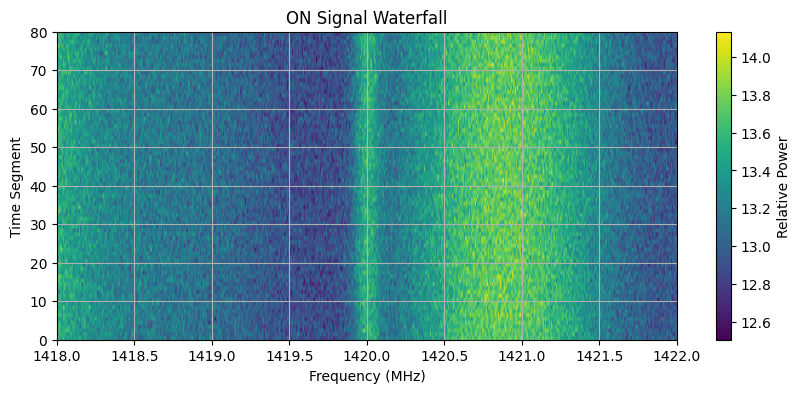

In [17]:
plt.imshow(
    on_signal,
    aspect="auto",
    origin="lower",
    extent=[f_min, f_max, 0, n_seg],
)

plt.colorbar(label="Relative Power")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Time Segment")
plt.title("ON Signal Waterfall")
plt.show()

In [18]:
n_samples2 = 2 * n_samples
freq2 = np.linspace(f_min, f_max, n_samples2)

spectral2 = gaussian_line(
    freq2,
    amplitude=line_amplitude,
    center=f0,
    sigma=line_sigma
)

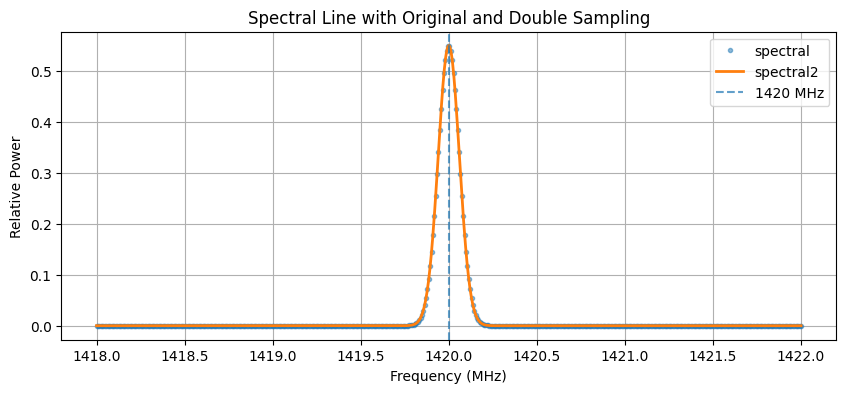

In [19]:
plt.plot(freq, spectral, "o", markersize=3, alpha=0.5, label="spectral")
plt.plot(freq2, spectral2, linewidth=2, label="spectral2")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Spectral Line with Original and Double Sampling")
plt.legend()
plt.show()

### Step 3 summary

The ON signal was created by adding a Gaussian spectral line centered at 1420 MHz to the same background used in the OFF signal.  
The clean spectral line was stored separately as `spectral`, while `spectral2` was generated using twice the number of frequency samples for later comparison with the upsampled signal.

## Step 4: Averaging over time

In this step, I compute the average signal over all time segments for both the OFF and ON signals.

This reduces the effect of random noise while preserving the underlying signal structure.

In [20]:
off_avg = np.mean(off_signal, axis=0)
on_avg = np.mean(on_signal, axis=0)

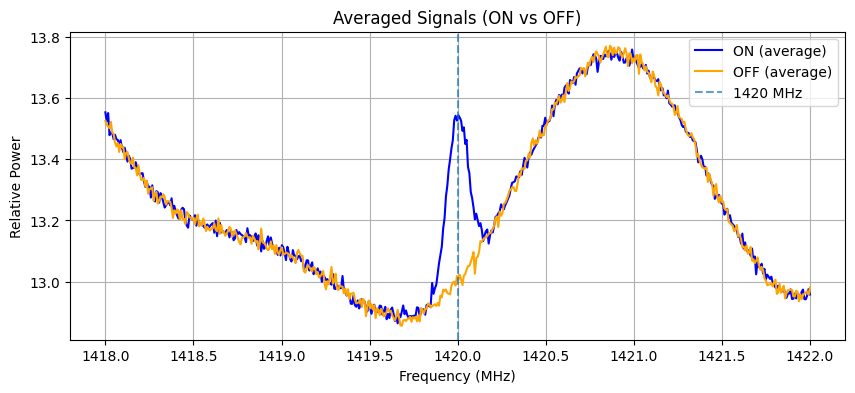

In [21]:
plt.plot(freq, on_avg, label="ON (average)", color="blue")
plt.plot(freq, off_avg, label="OFF (average)", color="orange")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Averaged Signals (ON vs OFF)")
plt.legend()
plt.show()

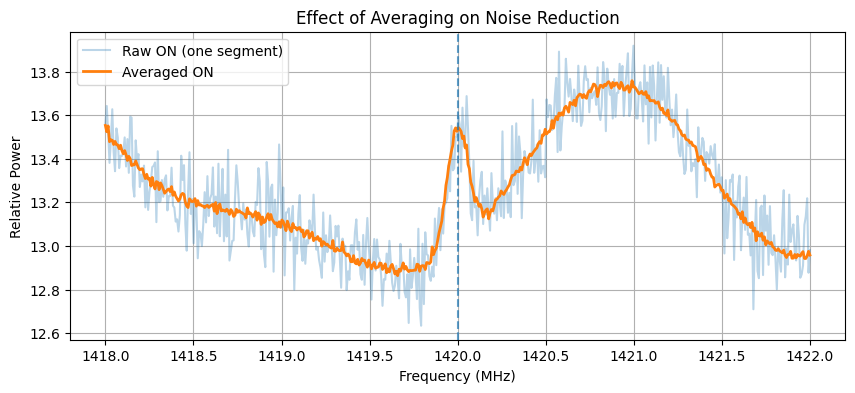

In [22]:
plt.plot(freq, on_signal[0], alpha=0.3, label="Raw ON (one segment)")
plt.plot(freq, on_avg, linewidth=2, label="Averaged ON")
plt.axvline(f0, linestyle="--", alpha=0.7)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Effect of Averaging on Noise Reduction")
plt.legend()
plt.show()

## Step 5: Background removal using ON/OFF calibration

The OFF signal is used as a reference background measurement.  
By dividing the averaged ON signal by the averaged OFF signal, the common background structure is reduced and the spectral line becomes easier to isolate.

The resulting signal is labeled `calibrated`.

In [23]:
calibrated = on_avg / off_avg

### Effect of calibration

The following plots illustrate:
- the averaged ON and OFF signals before calibration
- the calibrated signal after background removal

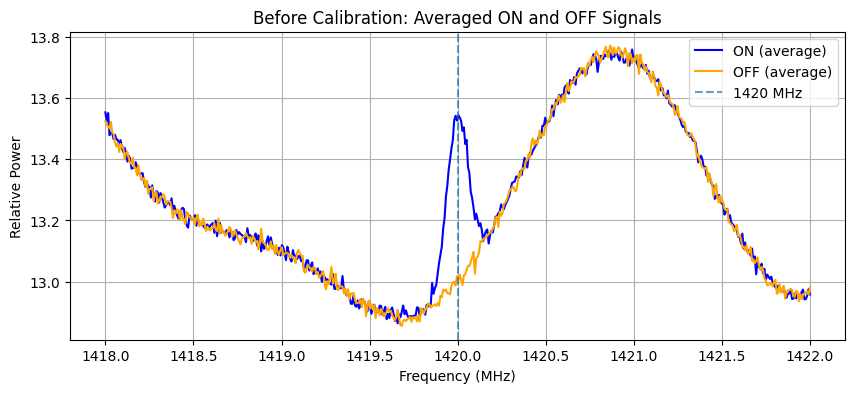

In [24]:
plt.plot(freq, on_avg, label="ON (average)", color="blue")
plt.plot(freq, off_avg, label="OFF (average)", color="orange")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Relative Power")
plt.title("Before Calibration: Averaged ON and OFF Signals")
plt.legend()
plt.show()

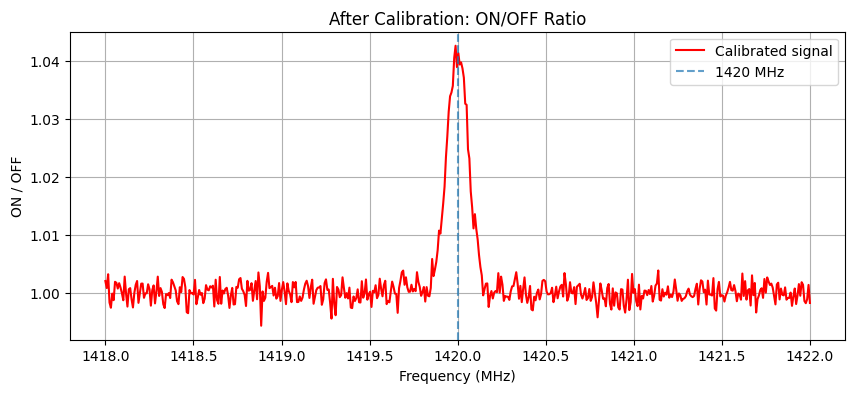

In [25]:
plt.plot(freq, calibrated, label="Calibrated signal", color="red")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("ON / OFF")
plt.title("After Calibration: ON/OFF Ratio")
plt.legend()
plt.show()

### Step 5 summary

The calibrated signal was obtained by dividing the averaged ON signal by the averaged OFF signal.  
This reduces the common background contribution and makes the spectral line region around 1420 MHz more distinguishable.

## Step 6: Moving average smoothing

In this step, I apply a moving average filter to the calibrated signal in order to reduce high-frequency noise while preserving the underlying spectral structure.

In [26]:
N = 11

In [27]:
def moving_average(signal, N):
  half = N // 2
  smoothed = np.zeros_like(signal)

  for i in range(len(signal)):
    start = max(0, i - half)
    end = min(len(signal), i + half + 1)
    smoothed[i] = np.mean(signal[start:end])

  return smoothed

In [28]:
smooth = moving_average(calibrated, N)

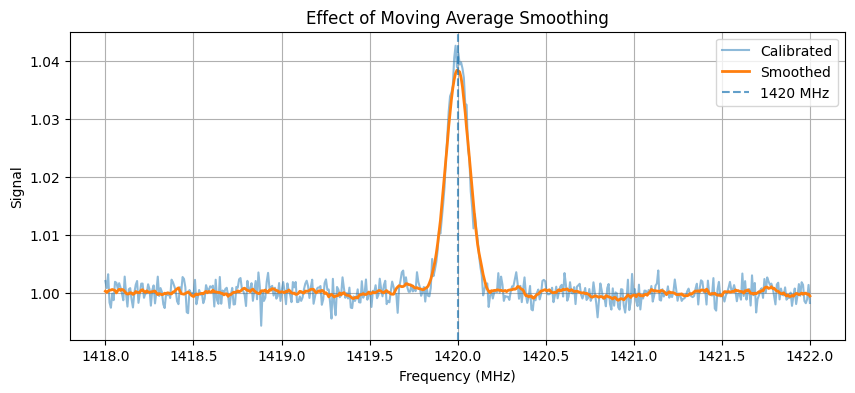

In [29]:
plt.plot(freq, calibrated, label="Calibrated", alpha=0.5)
plt.plot(freq, smooth, label="Smoothed", linewidth=2)
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")
plt.xlabel("Frequency (MHz)")
plt.ylabel("Signal")
plt.title("Effect of Moving Average Smoothing")
plt.legend()
plt.show()

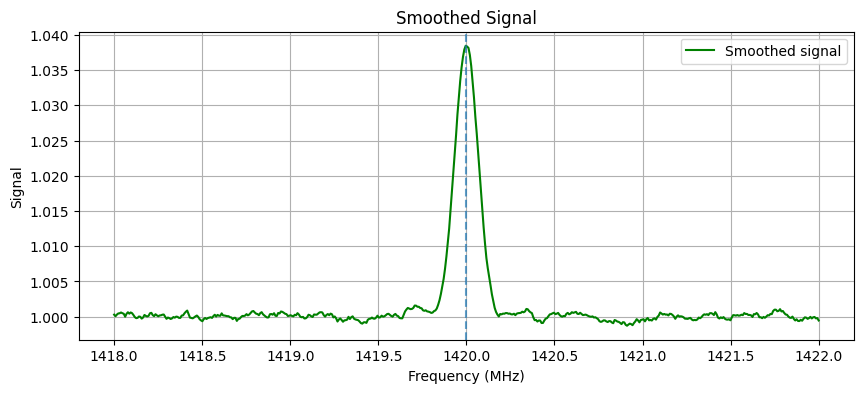

In [30]:
plt.plot(freq, smooth, label="Smoothed signal", color="green")
plt.axvline(f0, linestyle="--", alpha=0.7)
plt.xlabel("Frequency (MHz)")
plt.ylabel("Signal")
plt.title("Smoothed Signal")
plt.legend()
plt.show()

### Local view around the spectral line

To better observe the effect of smoothing, we focus on a narrow frequency region around 1420 MHz.

This allows us to examine how the moving average filter improves the visibility of the spectral line peak.

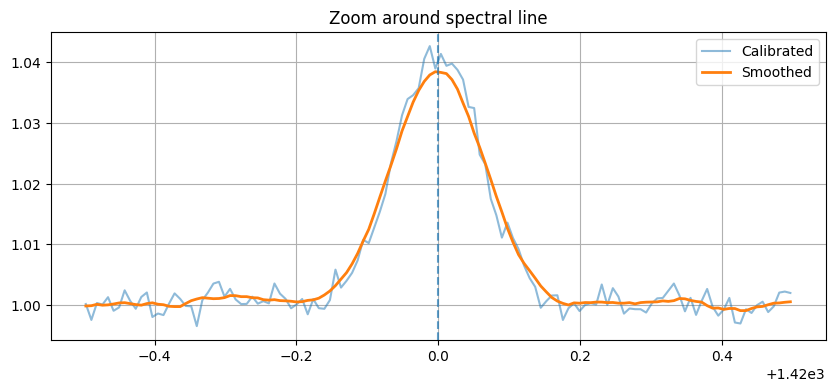

In [31]:
mask = (freq > 1419.5) & (freq < 1420.5)
plt.plot(freq[mask], calibrated[mask], label="Calibrated", alpha=0.5)
plt.plot(freq[mask], smooth[mask], label="Smoothed", linewidth=2)
plt.axvline(f0, linestyle="--", alpha=0.7)
plt.title("Zoom around spectral line")
plt.legend()
plt.show()

### Step 6 summary

The moving average filter reduces noise fluctuations while preserving the spectral line structure.  
The zoomed view shows that the peak around 1420 MHz becomes significantly clearer after smoothing.

## Step 7: Spectral line detection

In this step, I detect the spectral line by identifying peaks in the smoothed signal and computing the signal-to-noise ratio (SNR).

The goal is to determine the frequency of the spectral line and its corresponding region.

In [32]:
search_mask = (freq > 1419.7) & (freq < 1420.3)

local_freq = freq[search_mask]
local_smooth = smooth[search_mask]

local_peaks, _ = find_peaks(local_smooth)

peak_index_local = local_peaks[np.argmax(local_smooth[local_peaks])]
peak_freq = local_freq[peak_index_local]

# Convert local peak frequency back to global index
peak_index = np.argmin(np.abs(freq - peak_freq))

print(f"Detected peak frequency: {peak_freq:.4f} MHz")
print(f"Expected hydrogen line: {f0:.4f} MHz")
print(f"Difference: {abs(peak_freq - f0):.6f} MHz")

Detected peak frequency: 1419.9961 MHz
Expected hydrogen line: 1420.0000 MHz
Difference: 0.003914 MHz


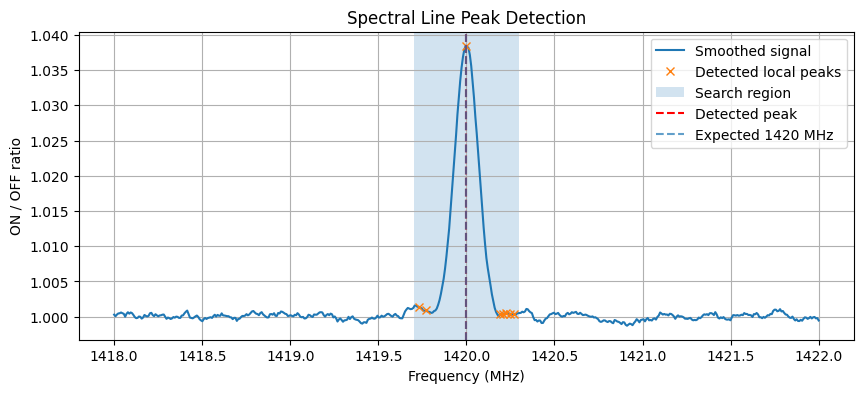

In [33]:
plt.plot(freq, smooth, label="Smoothed signal")

# Show only peaks found inside the local search region
plt.plot(
    local_freq[local_peaks],
    local_smooth[local_peaks],
    "x",
    label="Detected local peaks"
)

# Show the search region
plt.axvspan(1419.7, 1420.3, alpha=0.2, label="Search region")

plt.axvline(peak_freq, linestyle="--", color="red", label="Detected peak")
plt.axvline(f0, linestyle="--", alpha=0.7, label="Expected 1420 MHz")

plt.xlabel("Frequency (MHz)")
plt.ylabel("ON / OFF ratio")
plt.title("Spectral Line Peak Detection")
plt.legend()
plt.show()

In [34]:
signal_excess = on_avg - off_avg

noise_estimate = np.std(off_signal - off_avg, axis=0)
noise_estimate = np.mean(noise_estimate)

snr = signal_excess / noise_estimate
snr_positive = np.maximum(snr, 1e-12)
snr_db = 10 * np.log10(snr_positive)

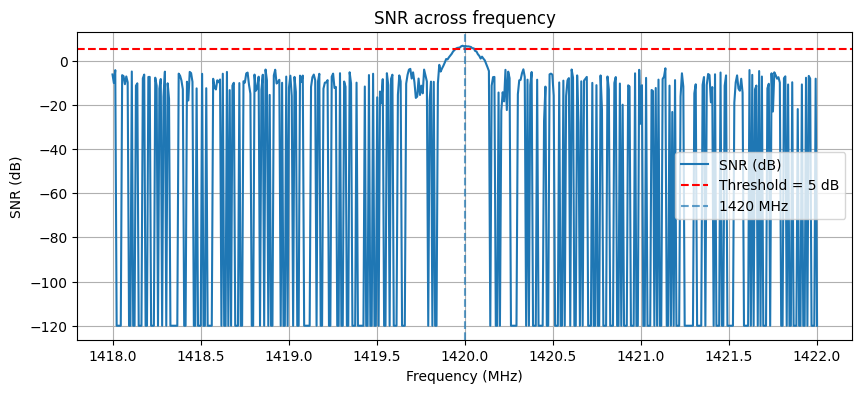

In [35]:
plt.plot(freq, snr_db, label="SNR (dB)")
plt.axhline(5, linestyle="--", color="red", label="Threshold = 5 dB")
plt.axvline(f0, linestyle="--", alpha=0.7, label="1420 MHz")

plt.title("SNR across frequency")
plt.xlabel("Frequency (MHz)")
plt.ylabel("SNR (dB)")
plt.legend()
plt.show()

In [36]:
mask_snr = snr_db > 5

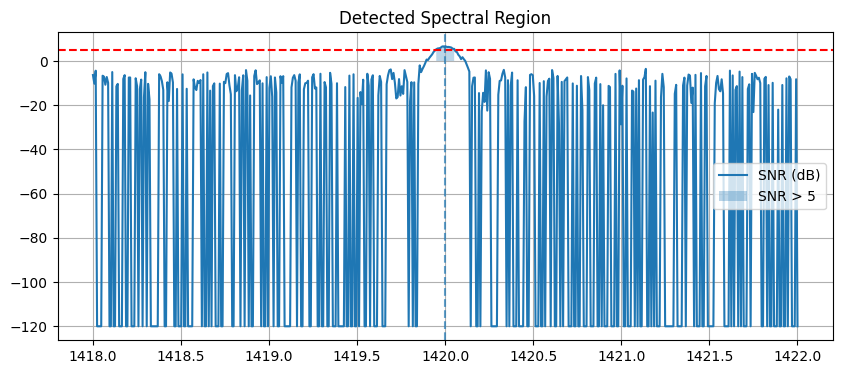

In [37]:
plt.plot(freq, snr_db, label="SNR (dB)")
plt.fill_between(freq, snr_db, where=mask_snr, alpha=0.3, label="SNR > 5")

plt.axhline(5, linestyle="--", color="red")
plt.axvline(f0, linestyle="--", alpha=0.7)

plt.title("Detected Spectral Region")
plt.legend()
plt.show()

In [38]:
indices = np.where(mask_snr)[0]

region = indices[
    (indices > peak_index - 10) &
    (indices < peak_index + 10)
]

In [40]:
print("Region length:", len(region))

if len(region) > 0:
  print(f"Detected region: {freq[region[0]]:.4f} - {freq[region[-1]]:.4f} MHz")
else:
  print("No valid spectral region detected.")

Region length: 14
Detected region: 1419.9491 - 1420.0509 MHz


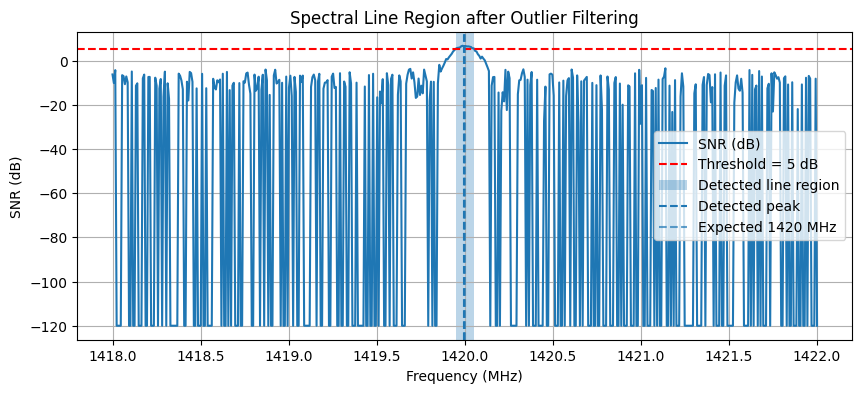

In [41]:
plt.plot(freq, snr_db, label="SNR (dB)")
plt.axhline(5, linestyle="--", color="red", label="Threshold = 5 dB")

if len(region) > 0:
  plt.axvspan(freq[region[0]], freq[region[-1]], alpha=0.3, label="Detected line region")

plt.axvline(peak_freq, linestyle="--", label="Detected peak")
plt.axvline(f0, linestyle="--", alpha=0.7, label="Expected 1420 MHz")

plt.xlabel("Frequency (MHz)")
plt.ylabel("SNR (dB)")
plt.title("Spectral Line Region after Outlier Filtering")
plt.legend()
plt.show()

### Step 7 summary

The spectral line was detected by identifying peaks in the smoothed signal.

The signal-to-noise ratio (SNR) was computed, and the spectral region was defined as the frequency range where SNR > 5.

This region corresponds to the hydrogen line around 1420 MHz.